# Full LOB for a Polymarket Digital Option
## Bertrand–Ma-Noh MFG — Fixed Implementation

Code-only notebook. For the full derivation, see the companion LaTeX document.

**Fixes in this version**:
1. Ask grid starts at $p$ and is power-law-spaced (fine near $p$) with a boolean flag detecting whether the best ask binds at the floor — so we can tell whether the spread is genuinely endogenous.
2. LP valuation grid uses Beta quantiles — concentrates resolution where the Beta density is high.
3. Log-spaced discount-rate grid for better resolution at low $r$ (patient LPs).
4. Trapezoidal aggregation weights handle the non-uniform $v$-grid correctly.

## 1. Imports

In [1]:
import numpy as np
from scipy.stats import beta as beta_dist
import matplotlib.pyplot as plt
import time

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12, 'axes.labelsize': 14,
    'axes.titlesize': 14, 'legend.fontsize': 11, 'lines.linewidth': 2,
    'figure.dpi': 120,
})

## 2. Ma-Noh primitives

Policy iteration HJB solver, uniformisation-based stationary distribution, quantile update. The HJB matrix is strictly diagonally dominant with excess $r > 0$, so $V_0$ is well-defined without normalisation.

In [2]:
def proj_0_lbar(x, lbar):
    return np.minimum(np.maximum(x, 0.0), lbar)

def rank_grid(N):
    return (np.arange(1, N+1) - 0.5) / N

def destination_indices(q, ds, db):
    q = np.asarray(q); N = q.size
    jp = np.empty(N, dtype=int); jm = np.empty(N, dtype=int)
    for i in range(N):
        jp[i] = int(np.argmin(np.abs(q - (q[i] + ds))))
        jm[i] = int(np.argmin(np.abs(q - max(q[i] - db, 0.0))))
    return jp, jm

def solve_hjb(q, u, jp, jm, rho, kappa, l_bar, psi, theta, margin, db,
              mu_exec, max_iter=80, tol=1e-10):
    N = len(q); Psi = 1+psi*u; Theta = 1+theta*(1-u)
    l = np.zeros(N); V = np.zeros(N)
    for it in range(max_iter):
        ls = l*Psi; lb = mu_exec*Theta
        pi = margin*lb*db*(q > 0).astype(float)
        A = np.zeros((N, N)); b = np.zeros(N)
        for i in range(N):
            A[i,i] = rho + ls[i] + lb[i]
            A[i,jp[i]] -= ls[i]; A[i,jm[i]] -= lb[i]
            b[i] = pi[i] - 0.5*kappa*l[i]**2
        try: Vn = np.linalg.solve(A, b)
        except: break
        ln = proj_0_lbar((Psi/kappa)*(Vn[jp]-Vn), l_bar)
        if np.max(np.abs(ln-l)) < tol: V,l = Vn,ln; break
        V,l = Vn,ln
    return V, l

def stat_dist(jp, jm, lp, lm):
    N = len(lp); rates = np.array(lp)+np.array(lm)
    bL = max(np.max(rates), 1e-12); P = np.zeros((N,N))
    for i in range(N):
        if rates[i] > 0:
            P[i,jp[i]] += lp[i]/bL; P[i,jm[i]] += lm[i]/bL
            P[i,i] += 1-rates[i]/bL
        else: P[i,i] = 1
    m = np.ones(N)/N; PT = P.T
    for _ in range(80000):
        mn = PT@m; s = mn.sum()
        if s <= 0: break
        mn /= s
        if np.max(np.abs(mn-m)) < 1e-14: m = mn; break
        m = mn
    return m

def quant_upd(u, q, m):
    M = np.cumsum(m); M = np.clip(M, 0, 1); Me = M.copy()
    for i in range(1, len(Me)):
        if Me[i] <= Me[i-1]: Me[i] = Me[i-1]+1e-12
    return np.interp(u, np.clip(Me, 0, 1), q, left=q[0], right=q[-1])

## 3. Parameters

In [3]:
p_mid   = 0.65
fee     = 0.02
alpha_F = 6.5; beta_F = 3.5
lam_arr = 10.0
delta_s = 1.0; delta_b_size = 1.0
kappa   = 0.4; l_bar = 3.0; psi = 0.3; theta = 0.7
N_total = 100.0; r_min = 0.05; r_max = 2.0

# FIXED: finer grids
N_v = 6
N_r = 6
N_a = 14
N_q = 35
q_max = 20.0

# FIXED: log-spaced r grid for better resolution at low r (patient LPs)
r_grid = r_min * (r_max/r_min)**np.linspace(0, 1, N_r)

omega = 0.10
outer_max = 18
cesaro_start = 11
sigma_smooth = 0.015

## 4. Beta-quantile $v$-grid constructor

Inverse-CDF sampling from a truncated Beta to concentrate grid points where density is high.

In [4]:
def beta_quantile_grid(alpha, beta, v_min_prob, v_max_prob, N):
    """
    Return N points spaced by Beta quantiles in probability interval
    [v_min_prob, v_max_prob]. This puts more grid points where the
    Beta density is higher, avoiding wasted resolution in low-density tails.
    """
    # Uniformly spaced probabilities mapped through the Beta inverse CDF
    probs = np.linspace(v_min_prob, v_max_prob, N)
    return beta_dist.ppf(probs, alpha, beta)

## 5. One-side Bertrand–Ma-Noh solver

Runs the full nested equilibrium for a single contract side (YES or NO):

- **Innermost**: policy iteration for the HJB at each $(v, r, a)$
- **Middle**: quantile fixed-point for KFE consistency
- **Outer**: Bertrand fixed-point on aggregate depth $\mathcal{D}(a)$ with Cesaro averaging over stabilised iterations

Returns: ask grid, equilibrium density $d(a)$, cumulative $\mathcal{D}_{cum}(a)$, 2D optimal-ask and mean-depth surfaces, the $v$-grid, the best ask, a boolean flag on whether the grid floor binds, and the $V_0$ values at the optimum.

In [5]:
def solve_one_side(p_fund, alpha_beta, beta_beta, side_label):
    """
    Solve the Bertrand-MaNoh equilibrium for one side of the book (YES or NO).
    Returns grids and equilibrium objects for plotting.
    """
    # --- FIX (2): Beta-quantile v_grid ---
    # LP valuations live in [0, p_fund(1-fee)], drawn from Beta(alpha,beta)
    v_upper_bound = p_fund * (1 - fee)
    # We want v in [0, v_upper_bound], concentrated by Beta density.
    # Use inverse-CDF sampling from Beta restricted to [0, v_upper_bound].
    # Probability mass of Beta in [0, v_upper_bound]:
    p_max_ask_side = beta_dist.cdf(v_upper_bound, alpha_beta, beta_beta)
    if p_max_ask_side < 0.05:
        # Very few LPs on this side (e.g. extreme p); use uniform fallback
        v_grid_s = np.linspace(0.01, max(v_upper_bound - 0.005, 0.02), N_v)
    else:
        # Beta-quantile grid from 5th to 99th percentile of the restricted Beta
        probs = np.linspace(0.05, 0.99, N_v) * p_max_ask_side
        v_grid_s = beta_dist.ppf(probs, alpha_beta, beta_beta)
        v_grid_s = np.clip(v_grid_s, 0.005, v_upper_bound - 0.005)
        v_grid_s = np.sort(np.unique(v_grid_s))
        while len(v_grid_s) < N_v:  # pad if unique dropped too many
            v_grid_s = np.concatenate([v_grid_s, [v_grid_s[-1] - 0.001]])
            v_grid_s = np.sort(np.unique(v_grid_s))

    # --- FIX (1): ask grid starts at exactly p_fund, fine near p ---
    # Use geometric spacing (fine near p_fund, coarser far away).
    a_lo = p_fund + 1e-4
    a_hi = min(0.995, 1.0 - fee/2)
    if a_lo >= a_hi:
        a_lo = a_hi - 0.05
    # Concentrate near p with a power-law spacing
    t = np.linspace(0, 1, N_a) ** 1.5
    a_grid_s = a_lo + (a_hi - a_lo) * t

    def phi_s(a):
        return lam_arr * (1.0 - beta_dist.cdf(a, alpha_beta, beta_beta))

    def margin_s(a, v):
        return a * (1 - fee) - v

    def solve_at(a_p, v_lp, rho, mu, ni=5):
        mg = margin_s(a_p, v_lp)
        if mg <= 0.0005:
            return 0.0, 0.0
        u = rank_grid(N_q)
        q = np.linspace(0, q_max, N_q)
        for _ in range(ni):
            jp, jm = destination_indices(q, delta_s, delta_b_size)
            V, l = solve_hjb(q, u, jp, jm, rho=rho, kappa=kappa, l_bar=l_bar,
                              psi=psi, theta=theta, margin=mg, db=delta_b_size,
                              mu_exec=mu)
            Psi = 1 + psi*u; Theta = 1 + theta*(1 - u)
            m = stat_dist(jp, jm, l*Psi, mu*np.ones_like(q)*Theta)
            qt = quant_upd(u, q, m)
            q = np.maximum(np.sort((1-0.15)*q + 0.15*qt), 0)
        return float(V[0]), float(np.dot(m, q))

    print(f"\n--- {side_label} side (p={p_fund:.3f}, Beta({alpha_beta},{beta_beta})) ---")
    print(f"  Ask grid: [{a_grid_s[0]:.4f}, {a_grid_s[-1]:.4f}] (N={N_a})")
    print(f"  LP v_grid: [{v_grid_s[0]:.3f}, {v_grid_s[-1]:.3f}] (N={N_v})")
    print(f"  r_grid: [{r_grid[0]:.3f}, {r_grid[-1]:.3f}] (N={N_r})")

    # --- Trapezoidal weights for non-uniform v_grid ---
    dv_weights = np.zeros(N_v)
    if N_v > 1:
        dv_weights[0] = (v_grid_s[1] - v_grid_s[0]) / 2
        dv_weights[-1] = (v_grid_s[-1] - v_grid_s[-2]) / 2
        for k in range(1, N_v - 1):
            dv_weights[k] = (v_grid_s[k+1] - v_grid_s[k-1]) / 2
    else:
        dv_weights[0] = 1.0

    dr_weights = np.zeros(N_r)
    if N_r > 1:
        dr_weights[0] = (r_grid[1] - r_grid[0]) / 2
        dr_weights[-1] = (r_grid[-1] - r_grid[-2]) / 2
        for l in range(1, N_r - 1):
            dr_weights[l] = (r_grid[l+1] - r_grid[l-1]) / 2
    else:
        dr_weights[0] = 1.0

    # --- Outer Bertrand fixed point ---
    D_a = np.ones(N_a) * 2.0
    D_ces = np.zeros(N_a); ces_n = 0
    a_star_2d = np.zeros((N_v, N_r))
    d_bar_2d = np.zeros((N_v, N_r))
    V0_best_2d = np.zeros((N_v, N_r))
    t0 = time.time()

    for oit in range(outer_max):
        mu_a = phi_s(a_grid_s) / np.maximum(D_a, 0.01)

        for kv in range(N_v):
            for kr in range(N_r):
                best = -np.inf; bj = 0; bdb = 0.0
                for j in range(N_a):
                    if margin_s(a_grid_s[j], v_grid_s[kv]) <= 0.0005:
                        continue
                    ni = 3 if oit < 10 else 5
                    V0j, dbj = solve_at(a_grid_s[j], v_grid_s[kv], r_grid[kr],
                                        mu_a[j], ni=ni)
                    if V0j > best:
                        best = V0j; bj = j; bdb = dbj
                a_star_2d[kv, kr] = a_grid_s[bj]
                d_bar_2d[kv, kr] = bdb
                V0_best_2d[kv, kr] = best

        # Aggregate D(a)
        D_new = np.zeros(N_a)
        step = np.diff(a_grid_s)
        step_at = np.concatenate([[step[0]], (step[:-1] + step[1:])/2, [step[-1]]])
        for kv in range(N_v):
            for kr in range(N_r):
                fv = beta_dist.pdf(v_grid_s[kv], alpha_beta, beta_beta)
                gr = 1.0 / (r_max - r_min)
                w = N_total * fv * dv_weights[kv] * gr * dr_weights[kr] * d_bar_2d[kv, kr]
                kern = np.exp(-0.5 * ((a_grid_s - a_star_2d[kv, kr]) / sigma_smooth)**2)
                kern_norm = np.sum(kern * step_at) + 1e-20
                D_new += w * kern / kern_norm

        D_new = np.maximum(D_new, 0.005)
        D_a = (1 - omega) * D_a + omega * D_new

        if oit >= cesaro_start:
            ces_n += 1
            D_ces += (D_a - D_ces) / ces_n

        if (oit + 1) % 5 == 0 or oit == 0:
            mid = N_v // 2
            print(f"  iter {oit+1:3d}: a*(v={v_grid_s[mid]:.2f}) in "
                  f"[{a_star_2d[mid,:].min():.4f}, {a_star_2d[mid,:].max():.4f}], "
                  f"D_max={D_a.max():.2f} [{time.time()-t0:.0f}s]")

    D_final = D_ces if ces_n > 0 else D_a

    # Cumulative
    D_cum = np.zeros(N_a)
    for i in range(N_a):
        if len(a_grid_s[i:]) > 1:
            D_cum[i] = np.trapz(D_final[i:], a_grid_s[i:])

    # Best ask: lowest a_j where D_final > small threshold
    thresh = 0.05 * D_final.max()
    above_thresh = np.where(D_final > thresh)[0]
    best_ask_idx = above_thresh[0] if len(above_thresh) > 0 else 0
    best_ask = a_grid_s[best_ask_idx]

    # Check: is best ask at the grid floor?
    floor_binds = best_ask_idx <= 1
    print(f"  Done [{time.time()-t0:.0f}s]. Best ask = {best_ask:.4f}, "
          f"floor binds: {floor_binds}")
    print(f"  a*_min = {a_star_2d.min():.4f}, a*_max = {a_star_2d.max():.4f}")

    return (a_grid_s, D_final, D_cum, a_star_2d, d_bar_2d, v_grid_s,
            best_ask, floor_binds, V0_best_2d)

## 6. Run both sides and compute the spread

The YES ask side uses Beta$(\alpha_F, \beta_F)$ with fundamental $p$. The NO ask side uses Beta$(\beta_F, \alpha_F)$ with fundamental $1-p$ (swapped parameters because $v_{NO} = 1 - v_{YES}$). The YES bid is obtained via $b = 1 - a_{NO}$. The spread $s = a_{YES}^\text{best} + a_{NO}^\text{best} - 1 \ge 0$ by no-arbitrage.

In [6]:
print("="*60)
print("Full LOB: YES + NO — FIXED VERSION")
print("="*60)
print(f"p = {p_mid}, fee = {fee}, Beta({alpha_F},{beta_F})")

(a_yes, d_yes, dc_yes, as_yes, db_yes, v_yes,
 ba_yes, floor_yes, V0_yes) = solve_one_side(p_mid, alpha_F, beta_F, 'YES')

(a_no, d_no, dc_no, as_no, db_no, v_no,
 ba_no, floor_no, V0_no) = solve_one_side(1 - p_mid, beta_F, alpha_F, 'NO')

# Convert NO ask to YES bid
b_yes_grid = 1.0 - a_no[::-1]
d_bid = d_no[::-1]
dc_bid = np.zeros(len(b_yes_grid))
for i in range(len(b_yes_grid)):
    if i > 0:
        dc_bid[i] = np.trapz(d_bid[:i+1], b_yes_grid[:i+1])

b_best_yes = 1.0 - ba_no
spread = ba_yes + ba_no - 1.0

print(f"\n{'='*60}")
print(f"EQUILIBRIUM RESULTS")
print(f"{'='*60}")
print(f"Best YES ask  = {ba_yes:.4f}  (floor binds: {floor_yes})")
print(f"Best NO ask   = {ba_no:.4f}  (floor binds: {floor_no})")
print(f"Best YES bid  = {b_best_yes:.4f}")
print(f"Spread        = {spread:.4f}")
print(f"Mid-price     = {p_mid:.4f}")
print(f"No-arbitrage  = {spread >= -1e-10}")
print(f"Spread is endogenous: {not (floor_yes and floor_no)}")

Full LOB: YES + NO — FIXED VERSION
p = 0.65, fee = 0.02, Beta(6.5,3.5)

--- YES side (p=0.650, Beta(6.5,3.5)) ---
  Ask grid: [0.6501, 0.9900] (N=14)
  LP v_grid: [0.340, 0.632] (N=6)
  r_grid: [0.050, 2.000] (N=6)
  iter   1: a*(v=0.56) in [0.7567, 0.8459], D_max=12.45 [4s]
  iter   5: a*(v=0.56) in [0.6501, 0.7844], D_max=27.51 [19s]
  iter  10: a*(v=0.56) in [0.7844, 0.7844], D_max=41.86 [39s]
  iter  15: a*(v=0.56) in [0.7312, 0.8459], D_max=57.41 [71s]
  Done [91s]. Best ask = 0.6501, floor binds: True
  a*_min = 0.6501, a*_max = 0.8794

--- NO side (p=0.350, Beta(3.5,6.5)) ---
  Ask grid: [0.3501, 0.9900] (N=14)
  LP v_grid: [0.105, 0.338] (N=6)
  r_grid: [0.050, 2.000] (N=6)
  iter   1: a*(v=0.27) in [0.4593, 0.5507], D_max=12.54 [5s]
  iter   5: a*(v=0.27) in [0.3887, 0.5027], D_max=24.53 [25s]
  iter  10: a*(v=0.27) in [0.5027, 0.5027], D_max=44.14 [116s]
  iter  15: a*(v=0.27) in [0.4593, 0.4593], D_max=57.71 [168s]
  Done [194s]. Best ask = 0.3501, floor binds: True
  a*_min

## 7. Visualisation


Generating plots...


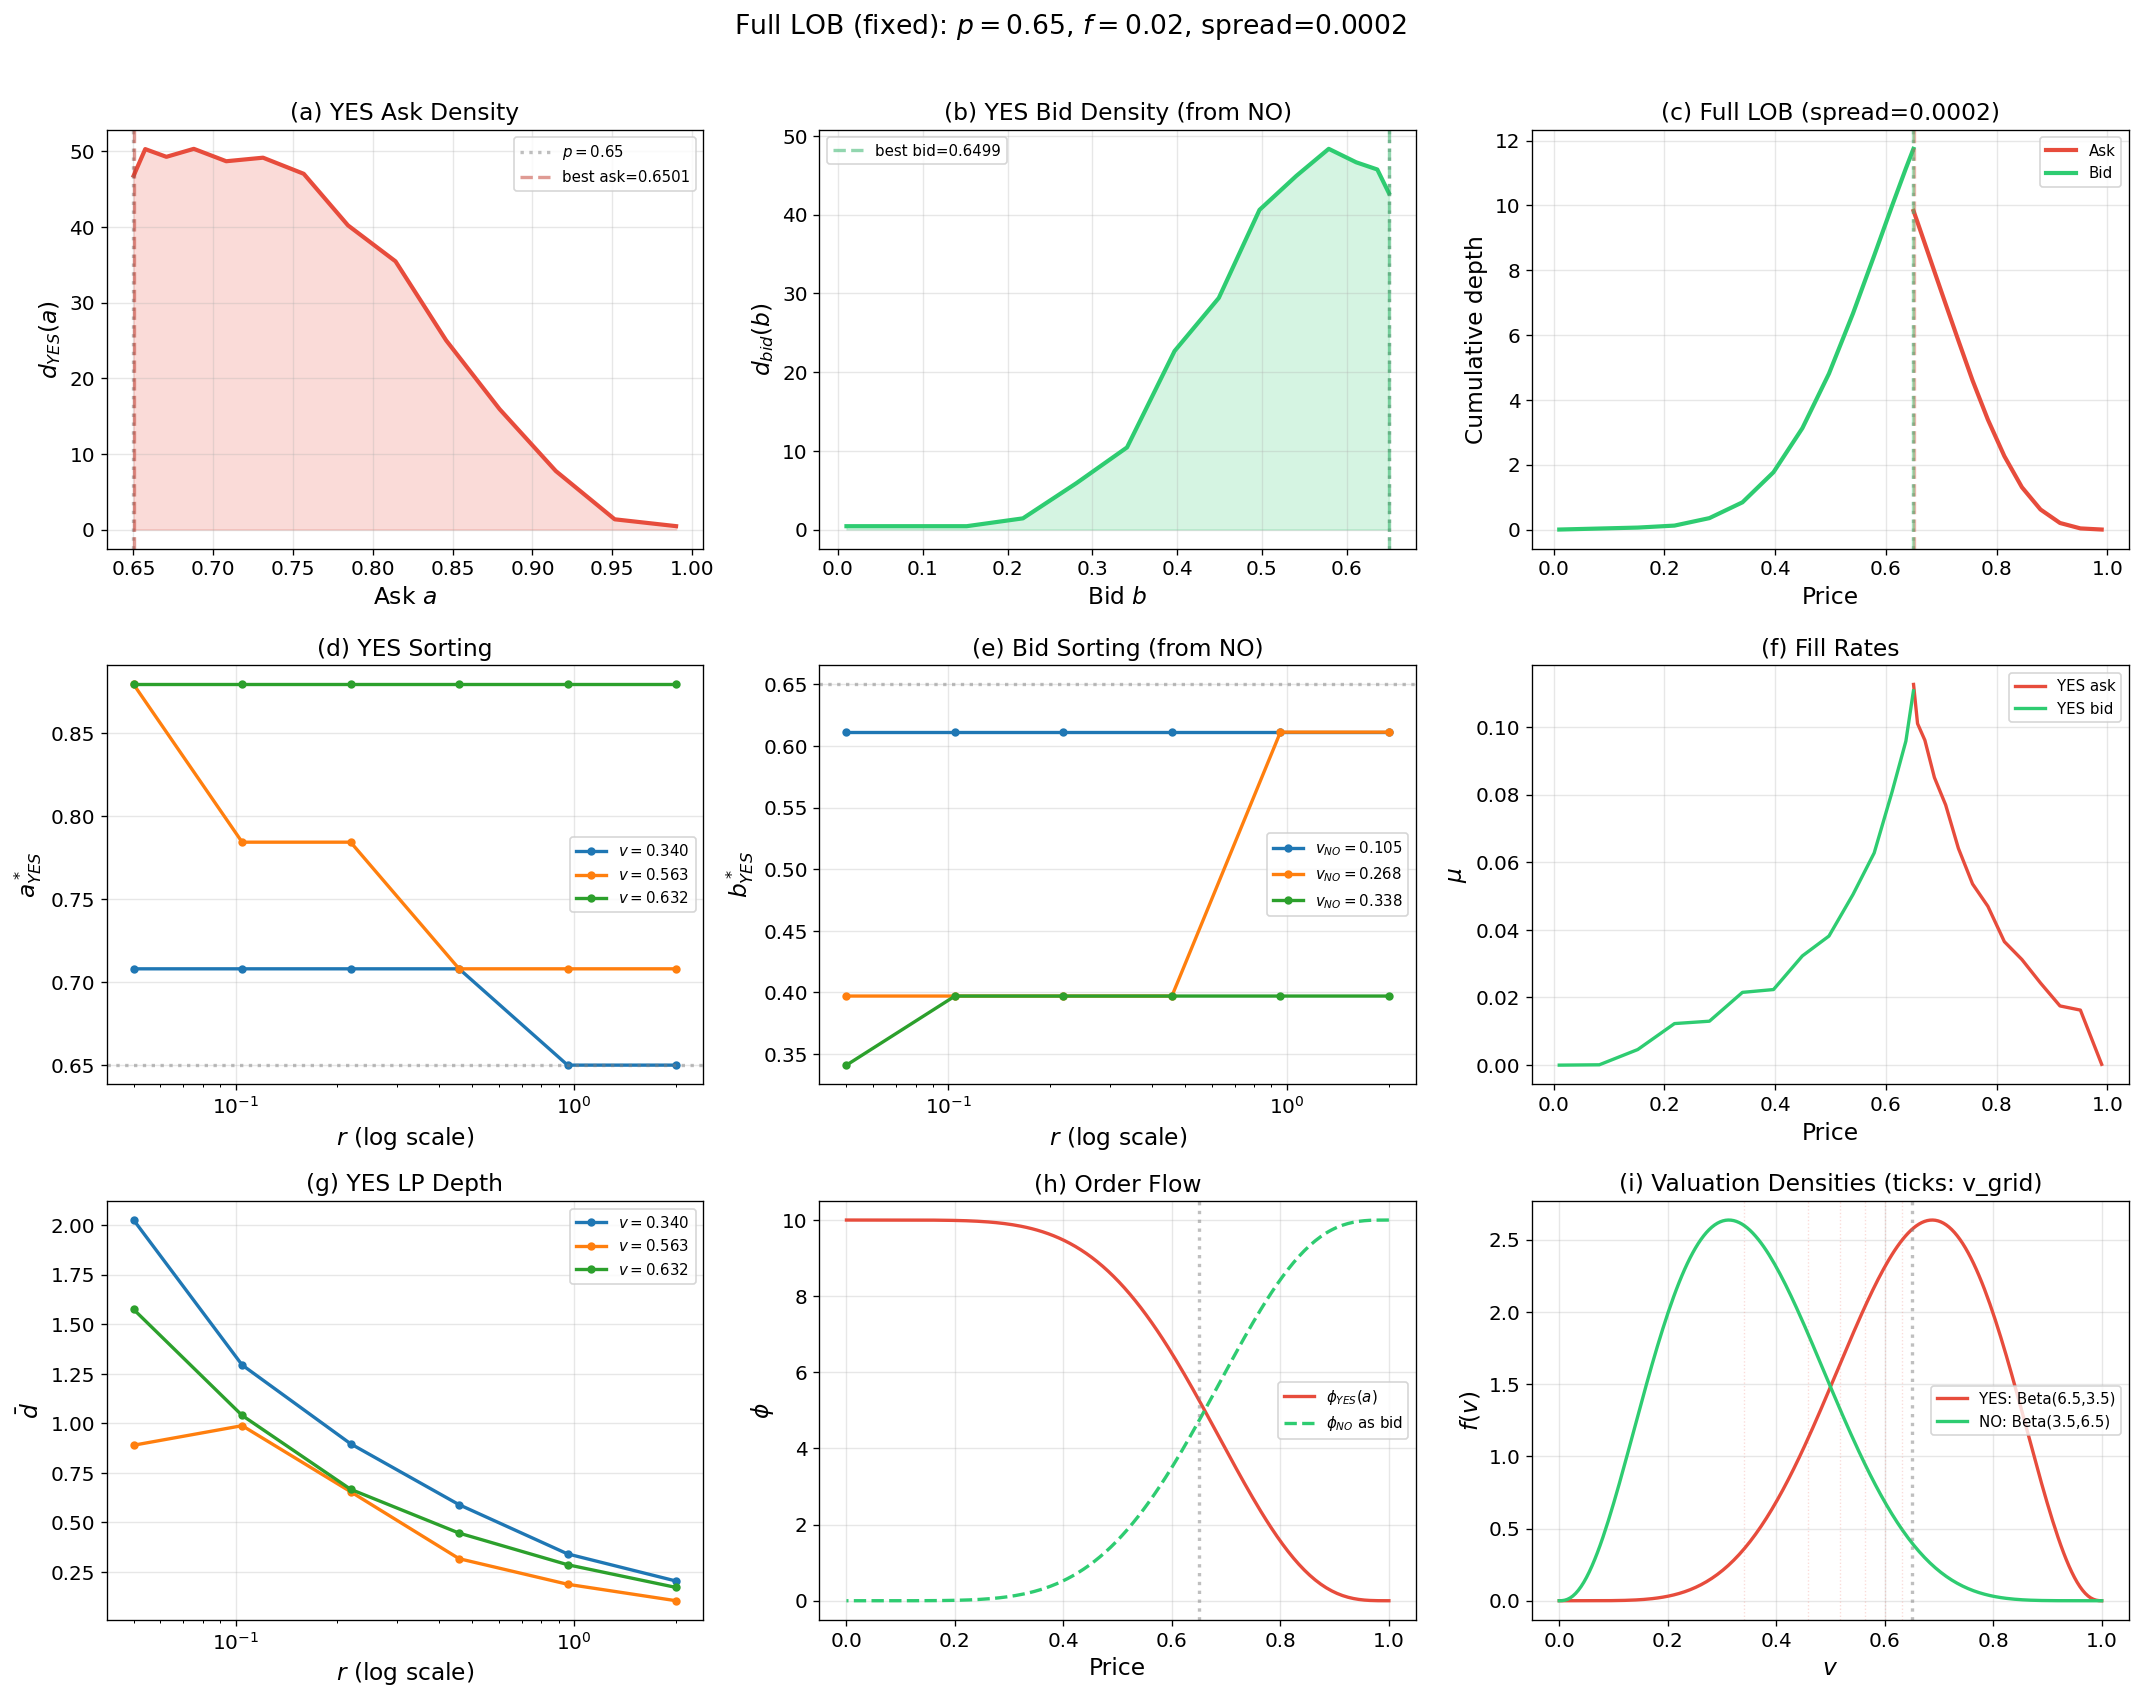

In [7]:
print("\nGenerating plots...")

mu_yes_final = lam_arr * (1 - beta_dist.cdf(a_yes, alpha_F, beta_F)) / np.maximum(d_yes, 0.005)
mu_no_final  = lam_arr * (1 - beta_dist.cdf(a_no,  beta_F, alpha_F)) / np.maximum(d_no,  0.005)

fig = plt.figure(figsize=(18, 14))

ax = fig.add_subplot(3, 3, 1)
ax.plot(a_yes, d_yes, color='#e74c3c', lw=2.5)
ax.fill_between(a_yes, 0, d_yes, alpha=0.2, color='#e74c3c')
ax.axvline(p_mid, color='gray', ls=':', alpha=0.5, label=f'$p={p_mid}$')
ax.axvline(ba_yes, color='#c0392b', ls='--', alpha=0.5, label=f'best ask={ba_yes:.4f}')
ax.set_xlabel('Ask $a$'); ax.set_ylabel('$d_{YES}(a)$')
ax.set_title('(a) YES Ask Density'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(3, 3, 2)
ax.plot(b_yes_grid, d_bid, color='#2ecc71', lw=2.5)
ax.fill_between(b_yes_grid, 0, d_bid, alpha=0.2, color='#2ecc71')
ax.axvline(p_mid, color='gray', ls=':', alpha=0.5)
ax.axvline(b_best_yes, color='#27ae60', ls='--', alpha=0.5, label=f'best bid={b_best_yes:.4f}')
ax.set_xlabel('Bid $b$'); ax.set_ylabel('$d_{bid}(b)$')
ax.set_title('(b) YES Bid Density (from NO)'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(3, 3, 3)
ax.plot(a_yes, dc_yes, color='#e74c3c', lw=2.5, label='Ask')
ax.plot(b_yes_grid, dc_bid, color='#2ecc71', lw=2.5, label='Bid')
ax.axvline(p_mid, color='gray', ls=':', alpha=0.5)
ax.axvline(ba_yes, color='#e74c3c', ls='--', alpha=0.4)
ax.axvline(b_best_yes, color='#2ecc71', ls='--', alpha=0.4)
ax.set_xlabel('Price'); ax.set_ylabel('Cumulative depth')
ax.set_title(f'(c) Full LOB (spread={spread:.4f})')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(3, 3, 4)
for kv in [0, N_v//2, N_v-1]:
    ax.plot(r_grid, as_yes[kv, :], 'o-', ms=4, label=f'$v={v_yes[kv]:.3f}$')
ax.axhline(p_mid, color='gray', ls=':', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('$r$ (log scale)'); ax.set_ylabel('$a^*_{YES}$')
ax.set_title('(d) YES Sorting'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(3, 3, 5)
for kv in [0, N_v//2, N_v-1]:
    ax.plot(r_grid, 1 - as_no[kv, :], 'o-', ms=4, label=f'$v_{{NO}}={v_no[kv]:.3f}$')
ax.axhline(p_mid, color='gray', ls=':', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('$r$ (log scale)'); ax.set_ylabel('$b^*_{YES}$')
ax.set_title('(e) Bid Sorting (from NO)'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(3, 3, 6)
ax.plot(a_yes, mu_yes_final, color='#e74c3c', lw=2, label='YES ask')
ax.plot(b_yes_grid, mu_no_final[::-1], color='#2ecc71', lw=2, label='YES bid')
ax.set_xlabel('Price'); ax.set_ylabel(r'$\mu$')
ax.set_title('(f) Fill Rates'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(3, 3, 7)
for kv in [0, N_v//2, N_v-1]:
    ax.plot(r_grid, db_yes[kv, :], 'o-', ms=4, label=f'$v={v_yes[kv]:.3f}$')
ax.set_xscale('log')
ax.set_xlabel('$r$ (log scale)'); ax.set_ylabel(r'$\bar{d}$')
ax.set_title('(g) YES LP Depth'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(3, 3, 8)
af = np.linspace(0, 1, 200)
ax.plot(af, lam_arr*(1 - beta_dist.cdf(af, alpha_F, beta_F)), color='#e74c3c', lw=2, label=r'$\phi_{YES}(a)$')
ax.plot(1-af, lam_arr*(1 - beta_dist.cdf(af, beta_F, alpha_F)), color='#2ecc71', lw=2, ls='--', label=r'$\phi_{NO}$ as bid')
ax.axvline(p_mid, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Price'); ax.set_ylabel(r'$\phi$')
ax.set_title('(h) Order Flow'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = fig.add_subplot(3, 3, 9)
ax.plot(af, beta_dist.pdf(af, alpha_F, beta_F), color='#e74c3c', lw=2, label=f'YES: Beta({alpha_F},{beta_F})')
ax.plot(af, beta_dist.pdf(af, beta_F, alpha_F), color='#2ecc71', lw=2, label=f'NO: Beta({beta_F},{alpha_F})')
ax.axvline(p_mid, color='gray', ls=':', alpha=0.5)
# Mark v_grid points to show sampling
for v in v_yes:
    ax.axvline(v, color='#e74c3c', alpha=0.2, ls=':', lw=0.8)
ax.set_xlabel('$v$'); ax.set_ylabel('$f(v)$')
ax.set_title('(i) Valuation Densities (ticks: v_grid)'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle(f'Full LOB (fixed): $p={p_mid}$, $f={fee}$, spread={spread:.4f}', fontsize=16, y=1.01)
plt.tight_layout()

## 8. Final summary

In [8]:
print(f"\n{'='*60}")
print(f"FINAL SUMMARY")
print(f"{'='*60}")
print(f"YES ask:  a* in [{as_yes.min():.4f}, {as_yes.max():.4f}], D_cum(best)={dc_yes[0]:.3f}")
print(f"NO ask:   a* in [{as_no.min():.4f}, {as_no.max():.4f}], D_cum(best)={dc_no[0]:.3f}")
print(f"Spread = {spread:.4f}")
print(f"Best ask floor binds: {floor_yes} (YES), {floor_no} (NO)")
print(f"Endogenous spread: {not (floor_yes and floor_no)}")


FINAL SUMMARY
YES ask:  a* in [0.6501, 0.8794], D_cum(best)=9.829
NO ask:   a* in [0.3887, 0.6590], D_cum(best)=11.745
Spread = 0.0002
Best ask floor binds: True (YES), True (NO)
Endogenous spread: False
